### Multiple Linear Regression

#### Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

#### Load Data

In [5]:
dataset = pd.read_csv('Multiple_linear_regression_dataset.csv')
dataset.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,74908.023769,154724.257103,92566.464419,India,123048.696981
1,190142.861282,130414.454952,270950.473689,Canada,330381.060751
2,146398.788362,96429.142443,436472.917938,Canada,363978.035408
3,119731.696839,172069.252956,366112.443205,India,342048.184953
4,31203.728088,152709.675883,403280.573931,USA,274807.779569


#### Split Independent and Dependent Data

In [9]:
X = dataset.iloc[:,:-1].values
y = dataset.iloc[:,-1].values
X.shape, y.shape

((500, 4), (500,))

#### Encoding the Data

In [11]:
ct = ColumnTransformer(
    transformers = [('encoder', OneHotEncoder(), [3])],
    remainder = 'passthrough'
)
X = np.array(ct.fit_transform(X))

In [15]:
X[13]

array([0.0, 1.0, 0.0, 0.0, 42467.82213565523, 179909.58342506125,
       19713.40568425295], dtype=object)

#### Split Data into Training and Testing

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=0)

In [18]:
X_train.shape, X_test.shape

((400, 7), (100, 7))

#### Training the Multiple Linear Regression Model

In [19]:
from sklearn.linear_model import LinearRegression

In [21]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

#### Predict the Test Set Results

In [28]:
y_pred = regressor.predict(X_test)
np.set_printoptions(precision=2)

In [29]:
y_pred_rs = y_pred.reshape(len(y_pred), 1)
y_test_rs = y_test.reshape(len(y_test), 1)
y_pred_rs.shape, y_test_rs.shape

((100, 1), (100, 1))

In [33]:
y_concat = np.concatenate((y_pred_rs, y_test_rs), 1)
y_concat[:5]

array([[275127.53, 300830.91],
       [219866.25, 237439.6 ],
       [ 54263.16,  76280.55],
       [214188.71, 181067.74],
       [307210.42, 289080.15]])

#### Root Mean Square Accuracy and Root Mean Square Error

In [55]:
y_pred = np.array(y_pred).flatten()
y_test = np.array(y_test).flatten()

# RMSE
error = y_test - y_pred
sq_error = error**2
RMSE = round(np.sqrt(np.mean(sq_error)), 2)

# RMSA
accuracy = (1 - abs((y_test - y_pred)/y_test)) * 100
RMSA = round(np.sqrt(np.mean(accuracy**2)), 2)

print(f"Accuracy = %.2f%%" % RMSA)
print("RMSE =", RMSE)

Accuracy = 92.19%
RMSE = 18882.24


#### Plot Prediction vs Actual

<function matplotlib.pyplot.show(close=None, block=None)>

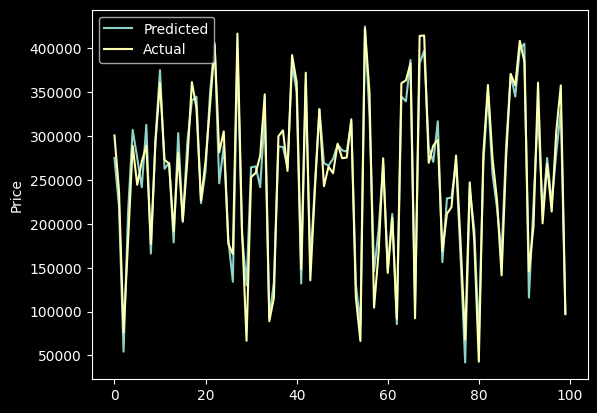

In [58]:
plt.style.use('dark_background')
xaxis = np.arange(len(y_pred))

plt.plot(xaxis, y_pred_rs)
plt.plot(xaxis, y_test_rs)
plt.ylabel('Price')
plt.legend(['Predicted', 'Actual'])
plt.show